In [3]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Grouping and Pivot: Ice cream Cones

In [4]:
cones = Table.read_table('https://raw.githubusercontent.com/lujiec2020/UMBC-IS296-SP24/refs/heads/main/data/cones.csv')

In [5]:
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [6]:
pivot_cones = cones.pivot('Color','Flavor', 'Price', np.max)
pivot_cones

Flavor,dark brown,light brown,pink
bubblegum,0,0,4.75
chocolate,5.25,4.75,0
strawberry,0,0,5.25


In [7]:
group_cones = cones.group(['Flavor','Color'],np.max)
group_cones

Flavor,Color,Price max
bubblegum,pink,4.75
chocolate,dark brown,5.25
chocolate,light brown,4.75
strawberry,pink,5.25


In [8]:
flavors = cones.group('Flavor')
flavors

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


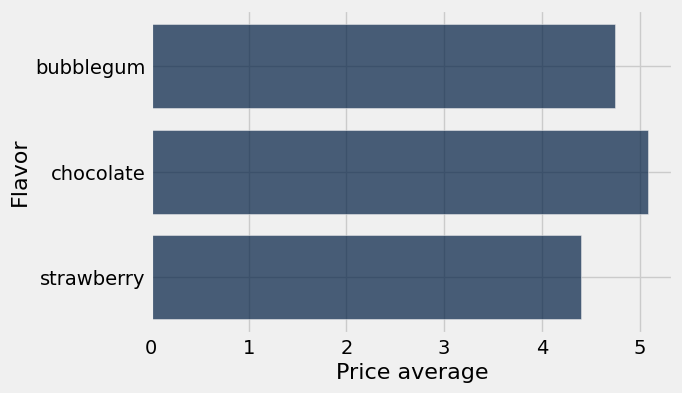

In [9]:
cones.drop('Color').group('Flavor', np.average).barh('Flavor')

In [10]:
cones.group(('Color','Flavor'))

Color,Flavor,count
dark brown,chocolate,2
light brown,chocolate,1
pink,bubblegum,1
pink,strawberry,2


In [11]:
cones.drop('Color').group('Flavor', np.average)

Flavor,Price average
bubblegum,4.75
chocolate,5.08333
strawberry,4.4


In [12]:
# Question: what if you don't drop color, what will happen?
cones.group('Flavor', np.average)

Flavor,Color average,Price average
bubblegum,,4.75
chocolate,,5.08333
strawberry,,4.4


In [13]:
cones.drop('Color').group('Flavor', min)

Flavor,Price min
bubblegum,4.75
chocolate,4.75
strawberry,3.55


## Grouping By One Column: Welcome Survey ##

In [14]:
survey = Table.read_table('https://raw.githubusercontent.com/lujiec2020/UMBC-IS296-SP24/refs/heads/main/data/welcome_survey_v2.csv')
survey
# what kind of table is it? a transaction table or aggregated/summary table, what is the unit of analysis?

Year,Extraversion,Number of textees,Hours of sleep
Third,4,6,4
Fourth,8,6,7
First,9,6,7
Third,2,3,6.75
Second,7,10,7
First,8,50,8
Fourth,4,5,10
Second,7,2,5
Fourth,3,7,5
Second,6,8,5.5


In [15]:
survey.group('Year', np.average)

Year,Extraversion average,Number of textees average,Hours of sleep average
First,5.8314,8.27326,7.12112
Fourth,5.37719,6.01754,7.13596
Fourth or above,6.33333,7.66667,7.2
Second,5.89051,7.47445,7.04623
Third,5.60837,5.71483,6.95913


In [16]:
by_extra = survey.group('Extraversion', np.average)
by_extra

Extraversion,Year average,Number of textees average,Hours of sleep average
1,,3.28571,6.61905
2,,4.1087,6.78804
3,,5.31788,7.01987
4,,6.44134,7.06145
5,,6.64398,7.08639
6,,6.53571,7.10714
7,,8.10484,7.10282
8,,9.5625,7.09375
9,,9.81429,7.09286
10,,10.7143,7.2619


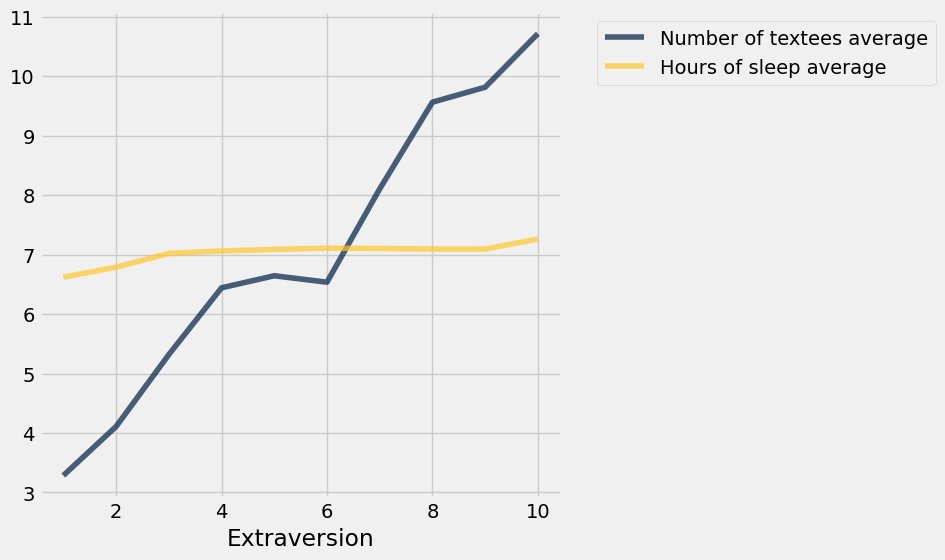

In [17]:
by_extra.select(0,2,3).plot('Extraversion') # Drop the 'Years average' column

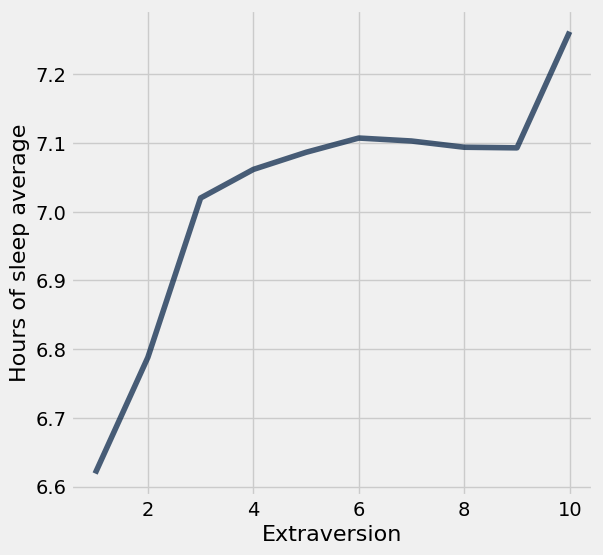

In [18]:
by_extra.select(0,3).plot('Extraversion')

## Grouping by Two Columns ##

In [19]:
survey = Table.read_table('https://raw.githubusercontent.com/lujiec2020/UMBC-IS296-SP24/refs/heads/main/data/welcome_survey_v3.csv')
survey

Year,Extraversion,Number of textees,Hours of sleep,Handedness,Sleep position
Third,4,6,4,Both,On your back
Fourth,8,6,7,Both,On your back
First,9,6,7,Both,On your back
Third,2,3,6.75,Left-handed,On your back
Second,7,10,7,Left-handed,On your back
First,8,50,8,Left-handed,On your back
Fourth,4,5,10,Left-handed,On your back
Second,7,2,5,Right-handed,On your back
Fourth,3,7,5,Right-handed,On your back
Second,6,8,5.5,Right-handed,On your back


In [20]:
survey.group(['Handedness','Sleep position'], np.mean).show()

Handedness,Sleep position,Year mean,Extraversion mean,Number of textees mean,Hours of sleep mean
Both,On your back,,7,5.25,6.125
Both,On your left side,,5.8,7.6,6.6
Both,On your right side,,5.28571,7.28571,7.42857
Both,On your stomach,,8,20,6
Left-handed,On your back,,5.45161,7.51613,7.1371
Left-handed,On your left side,,5.33333,5.7037,7.11111
Left-handed,On your right side,,5.56667,7.23333,7.03333
Left-handed,On your stomach,,6.75,7,6.70833
Right-handed,On your back,,5.57836,6.55224,7.12313
Right-handed,On your left side,,5.70349,7.62791,7.00291


In [21]:
#sum(g.column(2))
survey.num_rows

1326

## Pivot Tables

In [22]:
survey.pivot('Handedness', 'Sleep position')

Sleep position,Both,Left-handed,Right-handed
On your back,4,31,268
On your left side,5,27,344
On your right side,7,30,398
On your stomach,1,12,199


In [23]:
survey.pivot( 'Handedness', 'Sleep position', 'Hours of sleep', collect=np.average)

Sleep position,Both,Left-handed,Right-handed
On your back,6.125,7.1371,7.12313
On your left side,6.6,7.11111,7.00291
On your right side,7.42857,7.03333,7.05402
On your stomach,6,6.70833,7.18342


In [24]:
survey.group('Handedness', np.average)

Handedness,Year average,Extraversion average,Number of textees average,Hours of sleep average,Sleep position average
Both,,6,7.64706,6.79412,
Left-handed,,5.61,6.88,7.0475,
Right-handed,,5.78495,7.34243,7.0761,


In [27]:
sky = Table.read_table('./data/skyscrapers.csv')
sky

FileNotFoundError: [Errno 2] No such file or directory: './data/skyscrapers.csv'

In [26]:
#For each city, what’s the tallest building for each material?
#For each city, what’s the age difference between the oldest  steel building and the oldest concrete building?